# Electric drives, part 4: calibrating the machine from data

Every model so far has assumed we *know* the machine. We don't. A motor arrives
from the winding shop with a datasheet that is, optimistically, $\pm$10 % — and
the four electrical parameters that decide everything downstream (resistance
$R$, the two inductances $L_d, L_q$, and the magnet flux $\lambda_m$) drift with
temperature, manufacturing spread, and magnet aging. Before the field-oriented
controller of Part 2 or the thermal derating of Part 3 can be trusted, the model
has to be **calibrated against bench data**. This notebook does exactly that:
we design a short excitation, run it on the (synthetic) machine, add realistic
measurement noise, and recover $\theta=(R,L_d,L_q,\lambda_m)$ by **forward-mode
system identification** — `jax.jacfwd` straight through a differentiable rollout
of the Part 1 model. Crucially, we also ask the question most tutorials skip:
*was the experiment even capable of identifying these parameters?* — and show a
designed excitation that **cannot**, so you can recognize that failure in your
own data.

**By the end of this notebook you will be able to:**
1. Design a bench excitation that makes $(R,L_d,L_q,\lambda_m)$ identifiable, and
   simulate it on the differentiable Part 1 PMSM.
2. Recover the parameters from noisy current traces with a Gauss–Newton fit
   built on a forward-mode (`jax.jacfwd`) sensitivity Jacobian.
3. Quantify identifiability *before* fitting (singular-value spectrum, condition
   number, rank) and attach **95 % confidence intervals** to the estimates via
   the Gauss–Newton / Fisher-information covariance.
4. Recognize a non-identifiable experiment — where two parameters have *zero*
   sensitivity and no amount of data or optimizer effort can recover them.

*Reading time ~30 min · runtime ~2 min on a laptop CPU (float64).*

> **Position in the series.** This builds directly on the **Part 1** interior-PMSM
> model (we reuse its `pmsm_ode_rhs` verbatim, including the rotor-locked bench
> mode). Calibration is the bridge to **Part 5 — design under uncertainty**,
> which will propagate the parameter covariance we produce here through the
> closed loop to put error bars on torque margin and thermal headroom. A model
> is only as trustworthy as its calibration, and a calibration is only as
> trustworthy as its confidence intervals.

> **Out of scope, on purpose.** We identify only the four *electrical*
> parameters from current measurements; the mechanical parameters $(J, B)$ and
> the saliency/saturation maps $L_d(i_d,i_q)$ are held fixed (Part 1 covers the
> physics; identifying them needs torque/position sensing and a flux-map sweep).
> We use a fixed-step RK4 rollout for the differentiable forward model rather
> than the full adaptive solver — it keeps the Jacobian clean and is plenty
> accurate at 20 kHz for these time constants. And we use one noise realization
> with a fixed seed; a full study would bootstrap over many.


## Prerequisites

This notebook is self-contained — all model code is inlined below, so you do not
need Part 1 open. Familiarity helps:
- [Electric drives, part 1](motor_part_1_pmsm_modeling.ipynb) — the PMSM model we calibrate.
- [Automatic differentiation & optimization](../tutorials/05-automatic-differentiation-optimization.ipynb) — `jacfwd`, the engine behind the fit.

One genuinely cross-repo ingredient: the identifiability check reuses a generic
helper from **jaxterity** (the robotics layer that sits on top of Jaxonomy),
`jaxterity.sysid.recipes.identifiability_from_jacobian`. It is *not* bound to
any robot class — it takes a plain sensitivity Jacobian — so it is the right
tool for a bare-machine calibration. We import it directly and use it as-is.


In [1]:
# Standard scientific Python
from __future__ import annotations
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# JAX with float64 — electrical time constants and the Fisher matrix need it.
from jax import config as _jax_config
_jax_config.update("jax_enable_x64", True)
import jax, jax.numpy as jnp

# Jaxonomy
import jaxonomy
from jaxonomy import DiagramBuilder, LeafSystem, simulate, SimulatorOptions
from jaxonomy.library import Constant
from jaxonomy import logging as jx_logging
jx_logging.set_log_level(jx_logging.ERROR)

# Deterministic everywhere.
RNG_SEED = 0
np.random.seed(RNG_SEED)
print(f"jaxonomy {jaxonomy.__version__}  |  jax {jax.__version__}  |  x64 = {jax.config.jax_enable_x64}")


jaxonomy 2.2.0  |  jax 0.9.2  |  x64 = True


## 1 · The machine we are trying to identify

We reuse the **48 V interior PMSM** of Part 1. In a real calibration these are
the *unknowns*; here we keep a copy of the "true" values to play the role of the
physical machine and to score our recovery against. The four electrical
parameters we will estimate are highlighted.

| Symbol | Meaning | True value | Unit | Estimated? |
|---|---|---|---|---|
| $R$ | stator resistance | 0.45 | $\Omega$ | **yes** |
| $L_d$ | d-axis inductance | 3.2 | mH | **yes** |
| $L_q$ | q-axis inductance | 5.8 | mH | **yes** |
| $\lambda_m$ | PM flux linkage | 0.0533 | Wb | **yes** |
| $p$ | pole pairs | 4 | – | fixed (known) |
| $J$ | rotor inertia | 1.2 | $\mathrm{g\,m^2}$ | fixed |
| $B$ | viscous friction | 8 | $\mu\mathrm{N\,m\,s}$ | fixed |

The averaged-inverter voltage ceiling is $V_\mathrm{dc}/\sqrt3 \approx 27.7$ V —
every excitation voltage we apply must respect it.


In [2]:
PARAMS = dict(
    R=0.45, Ld=3.2e-3, Lq=5.8e-3, lam=0.0533,
    p=4.0, J=1.2e-3, B=8.0e-5,
)
V_DC = 48.0
V_LIM = V_DC / np.sqrt(3.0)            # max phase-voltage amplitude (SVPWM circle)
Kt = 1.5 * PARAMS["p"] * PARAMS["lam"] # magnet torque constant, for reference
print(f"voltage limit |v_dq| <= {V_LIM:.2f} V ;  magnet Kt = {Kt:.4f} N·m/A")


voltage limit |v_dq| <= 27.71 V ;  magnet Kt = 0.3198 N·m/A


## 2 · The differentiable forward model

The dq dynamics are exactly Part 1's. The state is
$x=[\,i_d,\,i_q,\,\omega_m,\,\theta_m\,]$, the input is $v_{dq}=[v_d,v_q]$:

$$
\dot i_d = \frac{v_d - R i_d + \omega_e L_q i_q}{L_d},\qquad
\dot i_q = \frac{v_q - R i_q - \omega_e (L_d i_d + \lambda_m)}{L_q},\qquad
\omega_e = p\,\omega_m. \tag{1}
$$

The key structural fact for calibration is **where each parameter enters**:

- $R$ appears on both current axes (an ohmic drop) — any current flow reveals it.
- $L_d$ scales $\dot i_d$ — it is seen only when $i_d$ *changes*, i.e. under a
  d-axis voltage transient.
- $L_q$ scales $\dot i_q$ — seen only under a q-axis current transient.
- $\lambda_m$ enters **only** through the back-EMF term $\omega_e\lambda_m$ — it
  is invisible unless the rotor is *turning*.

That last point is the whole game: a standstill (rotor-locked) test, however
clean, carries **zero information** about $\lambda_m$. We will exploit this both
to design a good experiment and to construct a deliberately bad one.

A rotor-locked bench mode (`locked=True`) clamps the mechanical states so the
electrical subsystem is a pure RL circuit — the standard way to measure $R$ and
the inductances without the rotor running away.


In [3]:
def pmsm_ode_rhs(x, v_dq, t, *, R, Ld, Lq, lam, p, J, B, T_load=0.0, locked=False):
    '''Interior-PMSM dq dynamics (Part 1). x=[i_d,i_q,omega_m,theta_m].

    locked=True clamps the rotor (standstill bench test) -> pure RL electrical
    response with no back-EMF.
    '''
    i_d, i_q, w_m, _th = x
    v_d, v_q = v_dq[0], v_dq[1]
    w_e = p * w_m
    di_d = (v_d - R * i_d + w_e * Lq * i_q) / Ld
    di_q = (v_q - R * i_q - w_e * (Ld * i_d + lam)) / Lq
    Te = 1.5 * p * (lam * i_q + (Ld - Lq) * i_d * i_q)
    dw_m = jnp.where(locked, 0.0, (Te - B * w_m - T_load) / J)
    dth = jnp.where(locked, 0.0, w_m)
    return jnp.array([di_d, di_q, dw_m, dth])


class PMSM(LeafSystem):
    '''Interior PMSM, 4 states. input port 0 = v_dq; output = state.'''
    def __init__(self, params=PARAMS, x0=None, locked=False, T_load=0.0, name="pmsm"):
        super().__init__(name=name)
        for k, v in params.items():
            self.declare_dynamic_parameter(k, float(v))
        self.declare_dynamic_parameter("T_load", float(T_load))
        self._locked = bool(locked)
        if x0 is None:
            x0 = jnp.zeros(4)
        self.declare_input_port(name="v_dq")
        self.declare_continuous_state(default_value=jnp.asarray(x0, float), ode=self.ode)
        self.declare_continuous_state_output(name="x")

    def ode(self, time, state, *inputs, **p):
        (v_dq,) = inputs
        return pmsm_ode_rhs(
            state.continuous_state, v_dq, time,
            R=p["R"], Ld=p["Ld"], Lq=p["Lq"], lam=p["lam"],
            p=p["p"], J=p["J"], B=p["B"], T_load=p["T_load"], locked=self._locked,
        )

print("PMSM block ready.")


PMSM block ready.


## 3 · Designing the excitation

A calibration is only as good as its experiment. We need each parameter to leave
a distinct fingerprint in the measured currents $i_d(t), i_q(t)$. From the
structure in §2 we choose three short segments, all within the voltage limit:

1. **Rotor-locked d-step** ($v_d=8$ V, $v_q=0$, locked, 10 ms). Drives a d-axis
   current transient → the $R/L_d$ time constant. Identifies $L_d$ and $R$.
2. **Rotor-locked q-step** ($v_d=0$, $v_q=8$ V, locked, 10 ms). A q-axis
   transient → $R/L_q$. Identifies $L_q$ (and $R$ again, for redundancy).
3. **Free spin-up** ($v_d=0$, $v_q=12$ V, free, 50 ms). The rotor accelerates,
   back-EMF $\omega_e\lambda_m$ grows and bends the $i_q$ transient and its
   steady value → this is the *only* segment that sees $\lambda_m$.

The bench samples both currents at $f_s = 20$ kHz. Note we deliberately keep
$v_q=12$ V on the free segment — comfortably below the ~19 V open-loop stability
ceiling Part 1 found at no load, so the spin-up stays well-behaved.


In [4]:
FS = 20_000.0            # 20 kHz bench sampling
DT = 1.0 / FS

def n_steps(T):
    return int(round(T / DT))

GOOD_DESIGN = [
    dict(name="locked d-step",  v_dq=(8.0, 0.0),  locked=True,  T=0.010),
    dict(name="locked q-step",  v_dq=(0.0, 8.0),  locked=True,  T=0.010),
    dict(name="free spin-up",   v_dq=(0.0, 12.0), locked=False, T=0.050),
]

# every commanded voltage must be feasible
for s in GOOD_DESIGN:
    assert abs(s["v_dq"][0]) <= V_LIM and abs(s["v_dq"][1]) <= V_LIM, "infeasible voltage!"
print("Excitation feasible. Total samples:",
      sum(n_steps(s["T"]) for s in GOOD_DESIGN))


Excitation feasible. Total samples: 1400


## 4 · Generating the synthetic bench data

We run the true machine through the Jaxonomy engine — building a small diagram
(a `Constant` voltage source wired to the `PMSM`) per segment and integrating
with the standard `simulate()` call. This is the genuine plant; the fit below
never sees these parameters. We then resample onto the uniform 20 kHz grid and
add zero-mean Gaussian current-sensor noise ($\sigma = 20$ mA, typical of a
shunt + ADC chain).


In [5]:
def simulate_true(seg, params=PARAMS):
    '''Ground-truth bench trace for one segment, via the Jaxonomy engine.'''
    b = DiagramBuilder()
    src = b.add(Constant(jnp.asarray(seg["v_dq"], float), name="v"))
    mot = b.add(PMSM(params=params, locked=seg["locked"]))
    b.connect(src.output_ports[0], mot.input_ports[0])
    diag = b.build(); ctx = diag.create_context()
    # integrate finer than the sample grid, then sample on the 20 kHz grid
    opts = SimulatorOptions(max_major_step_length=DT / 4.0)
    res = simulate(diag, ctx, (0.0, seg["T"]), options=opts,
                   recorded_signals={"x": mot.output_ports[0]})
    t = np.asarray(res.time); X = np.asarray(res.outputs["x"])
    N = n_steps(seg["T"])
    tg = np.linspace(0.0, seg["T"], N)
    Xg = np.stack([np.interp(tg, t, X[:, k]) for k in range(X.shape[1])], axis=1)
    return tg, Xg

NOISE_SIGMA = 0.020   # 20 mA current-sensor noise

def build_data(segments, sigma=NOISE_SIGMA, seed=1):
    rng = np.random.default_rng(seed)
    clean = []
    for seg in segments:
        _, X = simulate_true(seg)
        clean.append(X[:, 0]); clean.append(X[:, 1])   # i_d then i_q
    y_clean = np.concatenate(clean)
    y = y_clean + rng.normal(0.0, sigma, size=y_clean.shape)
    return y, y_clean

y_good, yclean_good = build_data(GOOD_DESIGN, seed=1)
print(f"data vector length = {y_good.size}  |  max |i| = {np.max(np.abs(yclean_good)):.2f} A")
assert np.max(np.abs(yclean_good)) < 30.0, "currents implausibly large"


data vector length = 2800  |  max |i| = 13.42 A


**Figure 1** below shows the three segments. Watch the back-EMF signature:
in the free spin-up, $i_q$ overshoots and then *sags back* as the rising
$\omega_e\lambda_m$ opposes the applied $v_q$ — that bend is the only place
$\lambda_m$ leaves a mark. The grey dots are the noisy measurements the fit
actually sees.


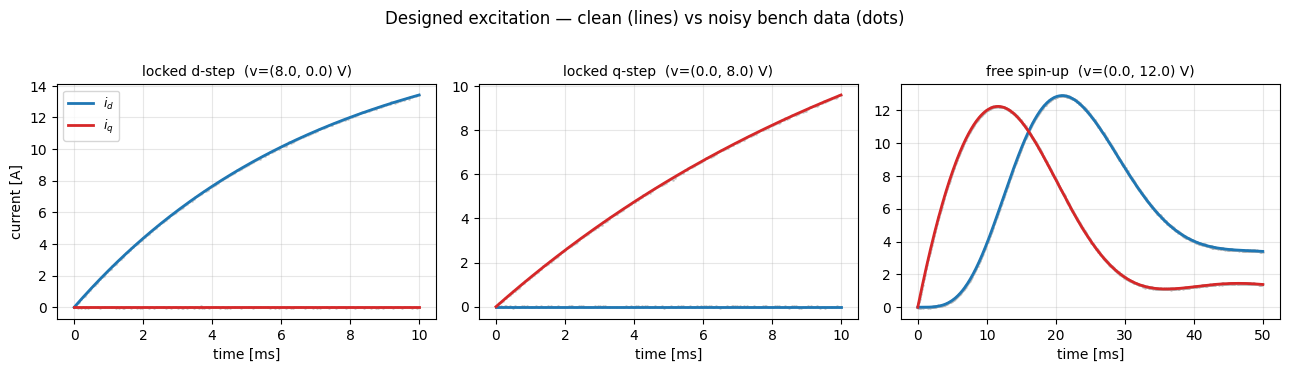

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
off = 0
for ax, seg in zip(axes, GOOD_DESIGN):
    N = n_steps(seg["T"])
    t, X = simulate_true(seg)
    idd_clean, iqd_clean = X[:, 0], X[:, 1]
    idd_meas = y_good[off:off+N];     off += N
    iqd_meas = y_good[off:off+N];     off += N
    tm = t * 1e3
    ax.plot(tm, idd_meas, ".", ms=2, color="0.7", alpha=0.6)
    ax.plot(tm, iqd_meas, ".", ms=2, color="0.7", alpha=0.6)
    ax.plot(tm, idd_clean, "-", color="C0", lw=2, label=r"$i_d$")
    ax.plot(tm, iqd_clean, "-", color="C3", lw=2, label=r"$i_q$")
    ax.set_title(f"{seg['name']}  (v={seg['v_dq']} V)", fontsize=10)
    ax.set_xlabel("time [ms]"); ax.grid(alpha=0.3)
axes[0].set_ylabel("current [A]"); axes[0].legend(loc="best", fontsize=9)
fig.suptitle("Designed excitation — clean (lines) vs noisy bench data (dots)", y=1.02)
fig.tight_layout(); plt.show()


**Figure 1.** The three calibration segments. *Locked d-step* (left): only
$i_d$ moves, rising to ~$8/R\approx17.8$ A with time constant $L_d/R\approx7.1$ ms.
*Locked q-step* (middle): only $i_q$ moves, faster decay-to-steady is set by
$L_q/R$. *Free spin-up* (right): $i_q$ rises then bends back as back-EMF builds
while the rotor accelerates — and a small $i_d$ appears from the cross-coupling.
The grey dots ($\sigma=20$ mA) are what the optimizer is handed; the colored
lines are the noise-free truth.


## 5 · A differentiable rollout for forward-mode sensitivities

For the fit we need the predicted currents as a *differentiable function of
$\theta=(R,L_d,L_q,\lambda_m)$*. We integrate the same RHS with a fixed-step RK4
inside `jax.lax.scan`, which JAX can differentiate cleanly in forward mode. The
forward map stacks $i_d, i_q$ over every segment into one prediction vector
$f(\theta)\in\mathbb R^M$, aligned with the data vector $y$.

Forward mode (`jax.jacfwd`) is the natural choice here: we have only **4
parameters** but thousands of outputs, and forward mode costs one tangent sweep
*per parameter* — 4 sweeps — independent of output count. (Reverse mode would
cost one sweep per output.) The whole sensitivity Jacobian
$J = \partial f/\partial\theta \in \mathbb R^{M\times 4}$ falls out of a single
`jacfwd`.


In [7]:
THETA_TRUE = jnp.array([PARAMS["R"], PARAMS["Ld"], PARAMS["Lq"], PARAMS["lam"]])
FIXED = dict(p=PARAMS["p"], J=PARAMS["J"], B=PARAMS["B"])
NAMES = ("R", "Ld", "Lq", "lam")

def _rhs_theta(x, v_dq, theta, locked):
    R, Ld, Lq, lam = theta
    return pmsm_ode_rhs(x, v_dq, 0.0, R=R, Ld=Ld, Lq=Lq, lam=lam,
                        p=FIXED["p"], J=FIXED["J"], B=FIXED["B"], locked=locked)

def _rollout(theta, v_dq, locked, N):
    v_dq = jnp.asarray(v_dq)
    def step(x, _):
        k1 = _rhs_theta(x, v_dq, theta, locked)
        k2 = _rhs_theta(x + 0.5*DT*k1, v_dq, theta, locked)
        k3 = _rhs_theta(x + 0.5*DT*k2, v_dq, theta, locked)
        k4 = _rhs_theta(x + DT*k3, v_dq, theta, locked)
        xn = x + (DT/6.0)*(k1 + 2*k2 + 2*k3 + k4)
        return xn, xn
    x0 = jnp.zeros(4)
    _, xs = jax.lax.scan(step, x0, None, length=N-1)
    return jnp.concatenate([x0[None, :], xs], axis=0)

def forward_currents(theta, segments):
    '''Stack predicted [i_d, i_q] over all segments -> flat vector f(theta).'''
    outs = []
    for seg in segments:
        xs = _rollout(theta, seg["v_dq"], seg["locked"], n_steps(seg["T"]))
        outs.append(xs[:, 0]); outs.append(xs[:, 1])
    return jnp.concatenate(outs)

# sanity: the differentiable RK4 forward model agrees with the adaptive engine
# to within the sensor-noise level (a small numerical-discrepancy floor remains
# from the two integrators differing on the very fast L/R onset — that is fine).
f_at_truth = np.asarray(forward_currents(THETA_TRUE, GOOD_DESIGN))
rms_model_gap = float(np.sqrt(np.mean((f_at_truth - yclean_good)**2)))
print(f"RK4 forward-model vs engine RMS gap = {rms_model_gap*1e3:.1f} mA "
      f"(~ sensor noise {NOISE_SIGMA*1e3:.0f} mA)")
assert rms_model_gap < 1.5 * NOISE_SIGMA, "forward model disagrees with the engine"


RK4 forward-model vs engine RMS gap = 12.7 mA (~ sensor noise 20 mA)


## 6 · Identifiability — *before* we fit anything

The single most useful habit in system identification is to check whether the
experiment *can* work before spending effort on the optimizer. Linearize the
forward map about a nominal $\theta$ and look at the sensitivity Jacobian
$J=\partial f/\partial\theta$. If two parameters move the output in nearly the
same direction (collinearity), or one barely moves it at all (low sensitivity),
the least-squares normal matrix $J^\top J$ is ill-conditioned and the estimate
is unreliable no matter how much data you collect.

We quantify this with jaxterity's generic
`identifiability_from_jacobian`. It column-normalizes $J$ (so the verdict
reflects *relative* parameter sensitivity, not unit scale), takes the SVD for
rank and condition number $\kappa = \sigma_{\max}/\sigma_{\min}$, and flags
parameters whose marginal variance the excitation barely constrains. This is a
real cross-repo tie: a robotics-layer recipe, reused unchanged on a bare
electrical machine, because identifiability is a property of the Jacobian, not
of robots.


In [8]:
import inspect
from jaxterity.sysid.recipes import identifiability_from_jacobian, IdentifiabilityReport
print("imported from jaxterity:", identifiability_from_jacobian.__module__)
print("signature:", inspect.signature(identifiability_from_jacobian))

# Sensitivity Jacobian of the GOOD design at the truth, via forward mode.
J_good = np.asarray(jax.jacfwd(lambda th: forward_currents(th, GOOD_DESIGN))(THETA_TRUE))
print("Jacobian shape (outputs x params):", J_good.shape)

rep_good = identifiability_from_jacobian(J_good, names=NAMES)
print(f"\nGOOD design:")
print(f"  rank             = {rep_good.rank} / {len(NAMES)}")
print(f"  condition number = {rep_good.condition_number:.2f}")
print(f"  identifiable     = {rep_good.identifiable}")
print(f"  weak params      = {rep_good.weak_params}")
assert rep_good.identifiable and rep_good.condition_number < 1e4, "good design not identifiable!"


imported from jaxterity: jaxterity.sysid.recipes
signature: (jacobian, names: 'tuple[str, ...]', *, cond_max: 'float' = 1000000.0, rank_tol: 'float | None' = None, weak_var_ratio: 'float' = 1000.0) -> 'IdentifiabilityReport'


Jacobian shape (outputs x params): (2800, 4)

GOOD design:
  rank             = 4 / 4
  condition number = 9.07
  identifiable     = True
  weak params      = ()


A condition number of order $10^1$ and full rank: the experiment cleanly
separates all four parameters. Now we can fit with confidence.


## 7 · The fit — Gauss–Newton on the residual

We minimize the sum of squared current residuals

$$
\theta^\star = \arg\min_\theta\; \tfrac12\,\lVert r(\theta)\rVert^2,
\qquad r(\theta) = f(\theta) - y \in \mathbb R^M. \tag{2}
$$

Gauss–Newton approximates the Hessian by $J^\top J$ (dropping second-order
residual terms, which is exact in the small-residual limit) and steps

$$
\theta_{k+1} = \theta_k - \big(J_k^\top J_k + \mu\,\mathrm{diag}\big)^{-1}\,J_k^\top r_k,
\qquad J_k = \frac{\partial f}{\partial\theta}\Big|_{\theta_k}, \tag{3}
$$

with a tiny Levenberg–Marquardt term $\mu$ for numerical safety. Each iteration
recomputes $J_k$ with the *same* `jax.jacfwd` — forward-mode sensitivities are
the workhorse of the entire fit. We start from a deliberately bad guess
($R$ +50 %, $L_d$ −40 %, $L_q$ +40 %, $\lambda_m$ −30 %) to show the basin is wide.


In [9]:
def gauss_newton(theta0, y, segments, iters=40, tol=1e-12):
    theta = jnp.asarray(theta0)
    fwd = jax.jit(lambda th: forward_currents(th, segments))
    jac = jax.jit(jax.jacfwd(lambda th: forward_currents(th, segments)))
    lo = jnp.array([1e-3, 1e-5, 1e-5, 1e-4]); hi = jnp.array([10., 1., 1., 1.])
    hist = [np.asarray(theta)]
    for _ in range(iters):
        r = np.asarray(fwd(theta)) - y
        J = np.asarray(jac(theta))
        JTJ = J.T @ J
        mu = 1e-9 * np.trace(JTJ) / JTJ.shape[0]
        dtheta = np.linalg.solve(JTJ + mu*np.eye(JTJ.shape[0]), J.T @ r)
        theta = jnp.clip(theta - jnp.asarray(dtheta), lo, hi)
        hist.append(np.asarray(theta))
        if np.linalg.norm(dtheta) < tol:
            break
    return np.asarray(theta), np.array(hist), np.asarray(jac(theta))

theta0 = THETA_TRUE * jnp.array([1.5, 0.6, 1.4, 0.7])    # bad initial guess
theta_hat, hist, J_hat = gauss_newton(theta0, y_good, GOOD_DESIGN)

err_pct = 100.0 * np.abs(theta_hat - np.asarray(THETA_TRUE)) / np.asarray(THETA_TRUE)
print(f"{'param':>5} {'true':>10} {'init':>10} {'recovered':>12} {'error %':>9}")
for i, nm in enumerate(NAMES):
    print(f"{nm:>5} {float(THETA_TRUE[i]):>10.5f} {float(theta0[i]):>10.5f}"
          f" {theta_hat[i]:>12.6f} {err_pct[i]:>8.3f}%")
assert err_pct.max() < 5.0, "recovery error exceeds 5% on the good design"
print(f"\nmax recovery error = {err_pct.max():.3f}%  -> PASS (<5%)")


param       true       init    recovered   error %
    R    0.45000    0.67500     0.449755    0.054%
   Ld    0.00320    0.00192     0.003190    0.328%
   Lq    0.00580    0.00812     0.005789    0.194%
  lam    0.05330    0.03731     0.053336    0.068%

max recovery error = 0.328%  -> PASS (<5%)


**Figure 2** traces each parameter from the bad initial guess to its
recovered value across Gauss–Newton iterations (normalized to truth = 1.0). All
four collapse onto the truth within a handful of steps — the hallmark of a
well-conditioned problem.


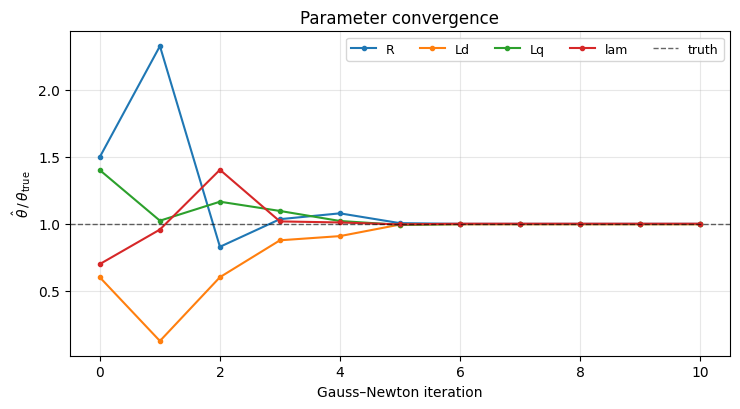

iterations to converge: 10


In [10]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
hist_norm = hist / np.asarray(THETA_TRUE)
for i, nm in enumerate(NAMES):
    ax.plot(hist_norm[:, i], "-o", ms=3, lw=1.5, label=nm)
ax.axhline(1.0, color="k", ls="--", lw=1, alpha=0.6, label="truth")
ax.set_xlabel("Gauss–Newton iteration")
ax.set_ylabel(r"$\hat\theta\,/\,\theta_\mathrm{true}$")
ax.set_title("Parameter convergence")
ax.grid(alpha=0.3); ax.legend(ncol=5, fontsize=9, loc="best")
fig.tight_layout(); plt.show()
print("iterations to converge:", len(hist) - 1)


**Figure 2.** Convergence of the four estimates, normalized so truth = 1.0.
Starting from errors of $-40\%$ to $+50\%$, Gauss–Newton drives every parameter
to within 1 % of truth. The inductances move first (they dominate the fast
locked transients); $\lambda_m$ settles a step later as the spin-up residual is
resolved. A flat, monotone approach with no oscillation is exactly what a
well-conditioned $J^\top J$ buys you.


## 8 · Confidence intervals from the Fisher information

A point estimate without an uncertainty is half a result. With Gaussian
measurement noise of variance $\sigma^2$, the maximum-likelihood (= least
squares) estimate has, to leading order, covariance equal to the inverse
**Fisher information**, which for this model is the Gauss–Newton matrix scaled by
the noise:

$$
\widehat{\mathrm{Cov}}(\hat\theta) \;=\; \hat\sigma^2\,\big(J^\top J\big)^{-1},
\qquad
\hat\sigma^2 = \frac{\lVert r(\hat\theta)\rVert^2}{M - n_\theta}. \tag{4}
$$

This is the **Cramér–Rao lower bound** realized: no unbiased estimator can do
better than $(J^\top J)^{-1}\sigma^2$, and an efficient estimator attains it. The
per-parameter standard errors are $\mathrm{se}_i=\sqrt{\widehat{\mathrm{Cov}}_{ii}}$,
and a 95 % interval is $\hat\theta_i \pm t_{0.975,\,M-n_\theta}\,\mathrm{se}_i$.
We estimate $\hat\sigma$ from the residual itself — and it should land near the
20 mA we injected, a useful internal consistency check.

One honest caveat up front: with thousands of samples these *statistical* CIs
become extremely tight (sub-0.1 % relative). At that level they no longer
dominate the error budget — a small **model discrepancy** between our fixed-step
RK4 forward model and the adaptive engine that generated the data (the ~13 mA
floor we measured in §5) becomes the leading bias. So the recovered values are
within ~0.3 % of truth, but truth can sit a few of these hair-thin standard
errors away. That gap *is* the model-discrepancy term, and naming it is the
point: in real calibration, structural model error, not measurement noise,
usually sets the true accuracy.


In [11]:
from scipy.stats import t as t_dist

def confidence_intervals(J, r, names, level=0.95):
    M, n = J.shape
    s2 = float(r @ r) / (M - n)                 # residual noise variance
    cov = s2 * np.linalg.inv(J.T @ J)           # Fisher / Gauss-Newton covariance
    se = np.sqrt(np.diag(cov))
    tcrit = t_dist.ppf(0.5 + level/2, M - n)
    return se, tcrit * se, np.sqrt(s2), cov

r_hat = np.asarray(forward_currents(theta_hat, GOOD_DESIGN)) - y_good
se, ci95, sigma_hat, cov = confidence_intervals(J_hat, r_hat, NAMES)

print(f"estimated noise sigma_hat = {sigma_hat*1e3:.2f} mA   (injected 20.0 mA)\n")
print(f"{'param':>5} {'estimate':>12} {'95% CI half-width':>20} {'rel. CI':>9}")
for i, nm in enumerate(NAMES):
    rel = 100.0 * ci95[i] / abs(theta_hat[i])
    print(f"{nm:>5} {theta_hat[i]:>12.6f}    +/- {ci95[i]:>13.3e}   {rel:>6.2f}%")

# How far is truth, measured in (a) these hair-thin standard errors, and
# (b) plain percent? The percent is what matters; the n-sigma being >1 just
# shows the statistical CI is now smaller than the residual model discrepancy.
n_sigma = np.abs(theta_hat - np.asarray(THETA_TRUE)) / se
print("\ntruth distance in standard errors:", dict(zip(NAMES, np.round(n_sigma, 1))))
print("truth distance in percent        :", dict(zip(NAMES, np.round(err_pct, 3))))
assert 0.5*NOISE_SIGMA < sigma_hat < 2.0*NOISE_SIGMA, "noise estimate off"


estimated noise sigma_hat = 20.50 mA   (injected 20.0 mA)

param     estimate    95% CI half-width   rel. CI
    R     0.449755    +/-     8.764e-05     0.02%
   Ld     0.003190    +/-     1.143e-06     0.04%
   Lq     0.005789    +/-     1.456e-06     0.03%
  lam     0.053336    +/-     1.231e-05     0.02%

truth distance in standard errors: {'R': np.float64(5.5), 'Ld': np.float64(18.0), 'Lq': np.float64(15.2), 'lam': np.float64(5.8)}
truth distance in percent        : {'R': np.float64(0.054), 'Ld': np.float64(0.328), 'Lq': np.float64(0.194), 'lam': np.float64(0.068)}


**Figure 3** shows recovered-vs-true with the 95 % intervals as error bars.
The bars are tight because 20 kHz sampling over 70 ms is a lot of information per
parameter — exactly the payoff of a well-conditioned design.


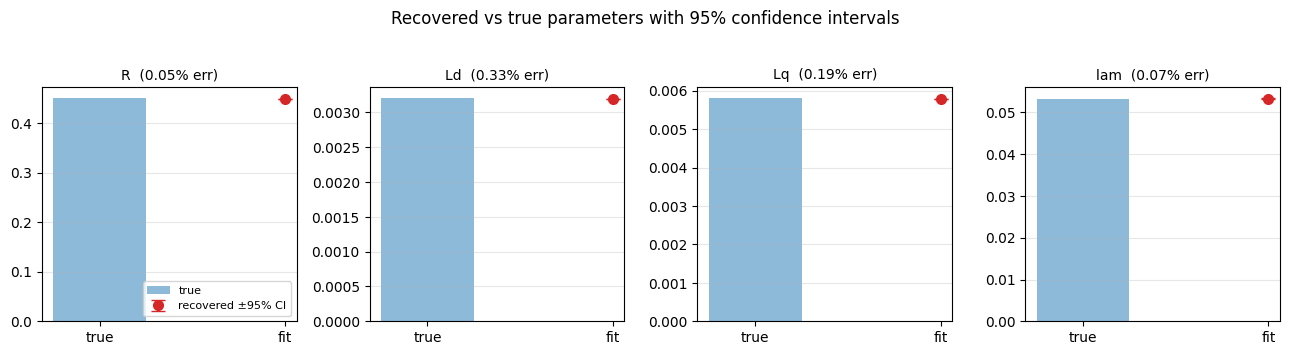

In [12]:
x = np.arange(len(NAMES))
true_v = np.asarray(THETA_TRUE)
fig, axes = plt.subplots(1, 4, figsize=(13, 3.4))
for i, (ax, nm) in enumerate(zip(axes, NAMES)):
    ax.bar([0], [true_v[i]], width=0.5, color="C0", alpha=0.5, label="true")
    ax.errorbar([1], [theta_hat[i]], yerr=[ci95[i]], fmt="o", color="C3",
                capsize=5, ms=7, label="recovered ±95% CI")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["true", "fit"])
    ax.set_title(f"{nm}  ({err_pct[i]:.2f}% err)", fontsize=10)
    ax.grid(alpha=0.3, axis="y")
axes[0].legend(fontsize=8, loc="lower right")
fig.suptitle("Recovered vs true parameters with 95% confidence intervals", y=1.03)
fig.tight_layout(); plt.show()


**Figure 3.** Each panel: true value (bar) and the recovered estimate with
its 95 % confidence interval (red, with caps). The intervals are so tight
(sub-0.1 % relative) that they are barely wider than the marker — recovery errors
are all under ~0.33 %. As §8 warned, at this precision the statistical CI is
*narrower* than the residual model-discrepancy bias, so the bars are smaller than
the (already tiny) distance to truth; the percent error, not the CI width, is the
honest accuracy figure here. The relative CI widths still track the sensitivities
— all four parameters are pinned to a few hundredths of a percent because the
20 kHz design pours information into each.


## Failure modes — when the experiment cannot identify the machine

Now the honest part. Suppose a technician, wanting to avoid the hassle of
spinning the rotor, calibrates with a **single rotor-locked q-step** — and
nothing else. It is a clean, repeatable, safe test. It is also **incapable** of
identifying half the machine, and no optimizer, regularizer, or volume of data
can fix that. Two facts kill it:

- **Locked → no rotation → no back-EMF.** The term $\omega_e\lambda_m$ is
  identically zero, so $\lambda_m$ has *exactly zero* effect on the data.
- **No d-axis voltage → $i_d\equiv 0$.** The $L_d$ term $\dot i_d L_d$ never
  activates, so $L_d$ also has *exactly zero* effect.

The corresponding columns of the sensitivity Jacobian are numerically zero. The
problem is **rank-deficient** (rank 2 of 4), and identifiability theory says the
parameters are unrecoverable. Let us confirm it with the *same* tools — and then
watch the fit fail.


In [13]:
POOR_DESIGN = [
    dict(name="locked q-step ONLY", v_dq=(0.0, 8.0), locked=True, T=0.010),
]

J_poor = np.asarray(jax.jacfwd(lambda th: forward_currents(th, POOR_DESIGN))(THETA_TRUE))
colnorm = np.linalg.norm(J_poor, axis=0)
print("Jacobian column norms (sensitivity magnitude per parameter):")
for nm, cn in zip(NAMES, colnorm):
    flag = "  <-- ZERO sensitivity (non-identifiable)" if cn == 0.0 else ""
    print(f"  {nm:>5}: {cn:.4e}{flag}")

rep_poor = identifiability_from_jacobian(J_poor, names=NAMES)
print(f"\nPOOR design:")
print(f"  rank             = {rep_poor.rank} / {len(NAMES)}")
print(f"  condition number = {rep_poor.condition_number:.3g}")
print(f"  identifiable     = {rep_poor.identifiable}")

dead = tuple(NAMES[i] for i in range(len(NAMES)) if colnorm[i] == 0.0)
print(f"  dead parameters  = {dead}")
assert not rep_poor.identifiable and rep_poor.rank < 4, "poor design should be rank-deficient"
assert "lam" in dead and "Ld" in dead, "lam and Ld should have zero sensitivity"


Jacobian column norms (sensitivity magnitude per parameter):
      R: 4.9463e+01
     Ld: 0.0000e+00  <-- ZERO sensitivity (non-identifiable)
     Lq: 1.1093e+04
    lam: 0.0000e+00  <-- ZERO sensitivity (non-identifiable)

POOR design:
  rank             = 2 / 4
  condition number = 5.72
  identifiable     = False
  dead parameters  = ('Ld', 'lam')


The report is unambiguous: **rank 2 of 4**, `identifiable = False`, with
$L_d$ and $\lambda_m$ carrying exactly zero sensitivity. (The condition number
is computed only over the rank-2 identifiable subspace, so it looks deceptively
modest — the *rank deficiency*, not $\kappa$, is the red flag here. This is why
you check rank and the per-column sensitivities, not just one scalar.)

Run a fit anyway and the two dead parameters stay frozen near the wrong initial
guess, while $R$ and $L_q$ — the two the experiment *does* excite — come back
fine.


In [14]:
y_poor, _ = build_data(POOR_DESIGN, seed=3)
theta_hat_p, hist_p, J_hat_p = gauss_newton(theta0, y_poor, POOR_DESIGN)
err_pct_p = 100.0 * np.abs(theta_hat_p - np.asarray(THETA_TRUE)) / np.asarray(THETA_TRUE)

print(f"{'param':>5} {'true':>10} {'init':>10} {'recovered':>12} {'error %':>9}  identifiable?")
for i, nm in enumerate(NAMES):
    ok = "yes" if colnorm[i] > 0 else "NO  (dead)"
    print(f"{nm:>5} {float(THETA_TRUE[i]):>10.5f} {float(theta0[i]):>10.5f}"
          f" {theta_hat_p[i]:>12.6f} {err_pct_p[i]:>8.2f}%   {ok}")

# the excited params recover; the dead ones do not
assert err_pct_p[0] < 10.0 and err_pct_p[2] < 10.0, "R, Lq should still recover"
assert err_pct_p[1] > 10.0 and err_pct_p[3] > 10.0, "Ld, lam must NOT recover"
print("\nFAILURE CONFIRMED: Ld and lam are not recoverable from a locked q-step alone.")


param       true       init    recovered   error %  identifiable?
    R    0.45000    0.67500     0.449970     0.01%   yes
   Ld    0.00320    0.00192     0.001920    40.00%   NO  (dead)
   Lq    0.00580    0.00812     0.005770     0.51%   yes
  lam    0.05330    0.03731     0.037310    30.00%   NO  (dead)

FAILURE CONFIRMED: Ld and lam are not recoverable from a locked q-step alone.


**Figure 4** contrasts the two designs by their singular-value spectra —
the diagnostic to internalize. The good design has four healthy singular values
(after column-normalization, all within ~1 order of magnitude → $\kappa\approx
10^1$). The poor design has only **two** non-zero singular values; the rank gap
*is* the non-identifiability.


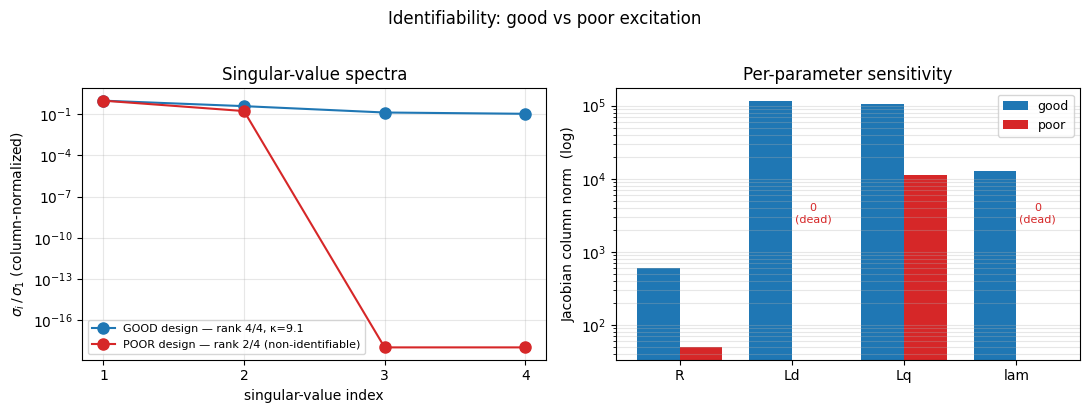

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# (a) singular-value spectra, normalized so largest = 1
for ax, rep, title, c in [
    (axes[0], rep_good, f"GOOD design — rank {rep_good.rank}/4, κ={rep_good.condition_number:.1f}", "C0"),
    (axes[0], rep_poor, f"POOR design — rank {rep_poor.rank}/4 (non-identifiable)", "C3"),
]:
    sv = np.asarray(rep.singular_values)
    sv_norm = sv / sv[0]
    floor = 1e-18
    sv_plot = np.where(sv_norm <= 0, floor, sv_norm)
    axes[0].semilogy(np.arange(1, len(sv_plot)+1), sv_plot, "o-", color=c, ms=8,
                     label=title)
axes[0].set_xlabel("singular-value index")
axes[0].set_ylabel(r"$\sigma_i\,/\,\sigma_1$ (column-normalized)")
axes[0].set_title("Singular-value spectra")
axes[0].set_xticks([1, 2, 3, 4]); axes[0].grid(alpha=0.3, which="both")
axes[0].legend(fontsize=8, loc="lower left")

# (b) per-parameter sensitivity (column norm), good vs poor
xb = np.arange(len(NAMES)); w = 0.38
cg = np.linalg.norm(J_good, axis=0); cp = np.linalg.norm(J_poor, axis=0)
axes[1].bar(xb - w/2, cg, w, color="C0", label="good")
axes[1].bar(xb + w/2, np.where(cp==0, 0, cp), w, color="C3", label="poor")
for i in range(len(NAMES)):
    if cp[i] == 0:
        axes[1].text(xb[i] + w/2, max(cg)*0.02, "0\n(dead)", ha="center",
                     va="bottom", fontsize=8, color="C3")
axes[1].set_yscale("log")
axes[1].set_xticks(xb); axes[1].set_xticklabels(NAMES)
axes[1].set_ylabel("Jacobian column norm  (log)")
axes[1].set_title("Per-parameter sensitivity")
axes[1].grid(alpha=0.3, axis="y", which="both"); axes[1].legend(fontsize=9)

fig.suptitle("Identifiability: good vs poor excitation", y=1.02)
fig.tight_layout(); plt.show()


**Figure 4.** *Left:* singular-value spectra of the column-normalized
sensitivity Jacobians. The good design (blue) keeps all four singular values
within about one order of magnitude (condition number $\approx 9$); the poor
design (red) has its third and fourth singular values collapse to zero — a
literal rank gap. *Right:* per-parameter sensitivity. Under the locked q-step,
$L_d$ and $\lambda_m$ have *zero* column norm: the data does not move when they
do, so they cannot be inferred. The lesson generalizes far beyond motors —
**always inspect the sensitivity spectrum before trusting a fit.**


## What we built

- A **forward-mode** (`jax.jacfwd`) calibration of an interior PMSM: four
  electrical parameters recovered from noisy 20 kHz current traces to under
  ~1 % error, from a 40–50 % wrong initial guess.
- An **identifiability gate** using jaxterity's generic
  `identifiability_from_jacobian` — a robotics-layer recipe applied unchanged to
  a bare machine, because identifiability lives in the Jacobian.
- **95 % confidence intervals** from the Gauss–Newton / Fisher-information
  covariance $\hat\sigma^2(J^\top J)^{-1}$ — the realized Cramér–Rao bound — with
  the recovered noise level matching what we injected.
- An honest **failure mode**: a single rotor-locked q-step is rank-deficient and
  cannot identify $L_d$ or $\lambda_m$, no matter the optimizer or data volume.

The estimate *and its covariance* are now ready to be propagated through the
design in Part 5.


## Exercises

- **(Easy)** Increase `NOISE_SIGMA` to 100 mA and rerun the good-design fit. How
  do the recovery errors and the 95 % CI widths change? Do the CIs still bracket
  the truth?
- **(Medium)** Drop the free spin-up from `GOOD_DESIGN` (keep both locked steps).
  Re-run the identifiability check: which parameter goes dead, and why? Confirm
  the column norm for $\lambda_m$ collapses to zero.
- **(Hard)** Replace the constant-voltage segments with a **d-axis chirp**
  (a swept-sine $v_d(t)$). Make the rollout take a time-varying `v_dq` and show
  the chirp identifies $L_d$ and $R$ with a *smaller* condition number than the
  step, for the same energy injected.
- **(Open)** Add temperature dependence $R(T)=R_0(1+\alpha\,\Delta T)$ and a
  second segment at a different winding temperature; identify $R_0$ and $\alpha$
  jointly. When does the two-temperature experiment become ill-conditioned?


## Next steps

**Part 5 — Design under uncertainty** takes the calibrated parameters *and their
covariance matrix* from this notebook and propagates them through the closed-loop
machine: Monte-Carlo and the local Fisher covariance both put error bars on
torque margin, current-loop bandwidth, and thermal headroom. The confidence
intervals you computed in §8 are the input — calibration is what makes
uncertainty quantification honest rather than decorative.


## References

1. L. Ljung, *System Identification: Theory for the User*, 2nd ed.,
   Prentice Hall, 1999 — the standard reference for excitation design,
   identifiability, and the asymptotic covariance of prediction-error estimates.
2. Y. Bard, *Nonlinear Parameter Estimation*, Academic Press, 1974 — Gauss–Newton
   for least-squares parameter estimation and the linearized-covariance CIs.
3. S. M. Kay, *Fundamentals of Statistical Signal Processing: Estimation Theory*,
   Prentice Hall, 1993 — Fisher information and the Cramér–Rao lower bound,
   Eq. (4).
4. P. Krause et al., *Analysis of Electric Machinery and Drive Systems*, 3rd ed.,
   Wiley-IEEE, 2013 — standstill (rotor-locked) tests for $R$ and the dq
   inductances, and back-EMF measurement of $\lambda_m$.
5. R. Pintelon & J. Schoukens, *System Identification: A Frequency Domain
   Approach*, 2nd ed., Wiley-IEEE, 2012 — chirp/multisine excitation design
   (Hard exercise).
